In [3]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()                              # <-- Edit as needed
NEURALNET = NOTEBOOKS.parents[0]                    # <-- Edit as needed
BAMBOO_SETUP = NOTEBOOKS.parents[2]                 # <-- Edit as needed
Z_OUTPUT_eos = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos')   # <-- Edit as needed
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
%load_ext autoreload

In [5]:
from NeuralNet.DataHandler import DataHandler
import logging
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_1013/Reco',
    tree_name='SL_res_2b_x',
    total_inputs= NEURALNET / 'input/vars40_new.txt',
    log_level=logging.DEBUG
)
# total_df = datahandler.start()
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_column_names_mismatch(total_df_unprep)
datahandler.data_inspection(total_df_unprep)
# datahandler.data_summary(total_df_unprep)
df = datahandler.preprocess_data(total_df_unprep)
datahandler.data_inspection(df)



Loading data...
	File: DY_dl_mll_50_1J
	File: DY_dl_mll_50_0J
	File: DY_dl_mll_10to50
	File: DY_dl_mll_50_2J
	File: bbWW_dl
	File: bbWW_sl
	File: bbtautau
	File: ZZ
	File: WW
	File: WZ
	File: Wjets_2J
	File: Wjets_0J
	File: Wjets_1J
	File: tbarWplus_sl
	File: tWminus_sl
	File: tWminus_dl
	File: tbarWplus_dl
	File: TTbar_dl
	File: TTbar_sl
	Total_df:
             event     genWeight  nAK4  nAK4_btag     lep0_pt  lep0_eta  lep0_phi  ak4_jet0_pt  ak4_jet0_eta  ak4_jet0_phi  ak4_jet1_pt  ak4_jet1_eta  ak4_jet1_phi  ak4_jet2_pt  ak4_jet2_eta  ak4_jet2_phi  ak4_btag0_pt  ak4_btag0_eta  ak4_btag0_phi  ak4_btag1_pt  ak4_btag1_eta  ak4_btag1_phi      met_pt   met_phi   bjets_mbb  bjets_dPhi  bjets_dEta  bjets_dR  bjets_pt_bb  trijet_mInv   trijet_pt  trijet_pt_rat     blnu_mT     blnu_pt  trijet_bijet_dR  trijet_bijet_dPhi  bjet_bijet_dR  bjet_bijet_dPhi     all_pt     all_mInv  all_jets_HT         mjj          File  Process
387977          18      3.805950     4          2   89.622681  1.1059

# Set up your model config

In [6]:
from NeuralNet.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture_in_yml=True,
    residual_network=True,
    hiddenlayers=[
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 35, "validation_split": 0.25}
)

In [5]:
%autoreload 2

# Run DNN

In [32]:
from NeuralNet.DNNModel import DNNModel, draw_all_stats
import NeuralNet.utils as utils

DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom', log_level=logging.DEBUG)
model_df = DNN.set_model_df_from_total_df(df)
X_train, X_test, Y_train, Y_test, evs_test, sw_train = DNN.Full_Splitting(model_df)

# input_layer, normalized_input = DNN.input_preprocessing(X_train)
# DNN.build_model(input_layer=input_layer, normalized_input=normalized_input, fixed_random_seed=True)
# DNN.train_model(X_train, Y_train, sw_train)
# DNN.save_model_info(X_train.columns, Y_train, Y_test)
# output_df, model_metrics = DNN.evaluate_and_predict(X_test, Y_test, evs_test)
# cm_norm_true, cm_norm_pred, diag_names = draw_all_stats(DNN_type=DNN.type, history=DNN.history, output_df=output_df, modeldir=DNN.modeldir, classes=DNN.classes)

Initializing model: multi_HH_ttbar_tW
HH_bbWW
Total sum of genWeights for HH_bbWW: 137.84710693359375 
Total sum of sample_weights for HH_bbWW: 2340784.0 
ttbar
Total sum of genWeights for ttbar: 414462528.0 
Total sum of sample_weights for ttbar: 18726300.0 
tW
Total sum of genWeights for tW: 10632820.0 
Total sum of sample_weights for tW: 9363136.0 


In [7]:
%autoreload 2

In [33]:
from tensorflow.keras.layers import Normalization
import numpy as np

# First approach
norm1 = Normalization(
    mean=X_train.mean(axis=0).to_numpy(),
    variance=X_train.var(axis=0).to_numpy()
)

X_normalized1 = norm1(X_train.to_numpy())
# Convert back to DataFrame to keep column names
X_normalized1 = pd.DataFrame(
    X_normalized1.numpy(),  # Convert from tensor to numpy array
    columns=X_train.columns
)
X_normalized1

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
0,-0.745912,-0.264737,2.008854,0.128957,1.358842,0.109372,-1.295396,0.184517,-0.167572,-0.387749,-1.687151,-0.110678,-0.583545,-0.497838,0.604534,-1.365006,0.186002,0.696051,-0.393476,-1.686789,-0.537228,-1.525058,0.711901,-1.378991,0.743096,0.843344,-0.406668,-0.532700,0.324036,0.527929,0.140937,1.019574,0.258726,-1.091620,-0.640097,-0.853506,0.425878,-0.227054,-0.170339,-0.824751
1,-0.745912,-0.264737,-0.609602,0.308732,-1.676561,-0.246683,-1.128615,-1.524935,-0.631886,-0.137072,0.123466,-0.176864,-0.184117,-0.131590,0.129779,-1.189262,-1.521500,0.006123,-0.139737,0.124686,-1.106981,1.094030,0.224267,1.433193,-0.814755,1.003082,-0.596326,-0.445004,-0.421044,0.340903,-0.456739,0.002564,-0.395448,0.199584,-0.423944,0.207450,-0.023299,-0.781663,-0.431933,-0.055363
2,0.357777,-0.264737,-0.111997,1.696704,1.302955,1.546589,-0.942250,-0.840118,-0.452131,0.661974,1.097410,0.022743,1.060916,1.483374,-0.626169,0.701403,1.098083,-0.350639,-0.945784,-0.289074,1.167846,0.620899,-0.068487,-1.204862,1.317887,0.901124,-0.874872,1.173924,1.058735,-0.007240,0.681521,0.833982,-0.869080,-0.229681,-0.856102,-0.790177,-0.823333,1.073294,0.761205,2.190251
3,-0.745912,-0.264737,0.093745,0.575191,0.548846,-1.075791,-1.008963,0.227722,-0.953286,1.647778,1.452220,-0.765181,-0.435087,1.410464,-0.975735,-1.063180,0.229157,-0.961286,0.549741,-1.583484,0.040693,-0.807903,-0.600819,1.434967,-1.279438,1.342752,-1.207919,-0.688522,-0.655697,1.301636,-0.272358,-0.744453,-0.861115,-0.261961,-1.157454,-0.523057,-0.255698,-0.769248,-1.141673,-0.121502
4,-0.745912,-0.264737,-0.773753,1.141286,1.291203,-0.677848,1.357179,-0.001435,-0.631886,0.949211,-0.596506,-0.479427,0.334523,1.185547,-0.445127,1.430116,0.000261,-0.341200,0.347572,1.185045,-0.332796,-1.374021,-0.324489,-1.027693,-0.831577,0.089827,-0.468686,-0.658033,-0.558880,-0.315289,-1.023177,-0.613872,-0.259130,-0.404438,-1.047565,-0.280717,-0.565103,-0.928926,-0.758096,-0.296231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872622,1.461467,-0.264737,-0.391652,-0.042874,1.174570,-0.640293,-1.115487,0.565992,-0.408939,0.152384,-0.058687,-0.288224,-1.309211,-1.166134,-0.857769,-0.453745,1.559350,-1.022634,-0.617356,0.636235,0.198840,1.708792,-0.994316,0.805396,-0.150370,-0.811019,-0.625716,-0.593744,-0.164256,0.773623,-0.674376,0.209228,-1.009262,-0.138905,-1.508951,-0.413701,2.100857,-0.373720,-0.221471,0.033944
1872623,-0.745912,-0.264737,0.388021,0.524367,1.287353,0.159927,0.352510,-1.597885,-0.718270,-0.769821,0.177615,-0.270364,0.723692,0.144832,0.671944,0.371457,-1.594367,-1.053308,0.274588,0.014129,-0.228761,-0.360100,-0.408075,1.400463,0.064055,0.675548,0.458167,-0.819984,-0.349325,1.598599,0.292284,-0.059475,-1.040561,0.065010,-1.761881,0.172571,-0.496771,-0.660122,-0.414743,-0.252017
1872624,-0.745912,-0.264737,-0.844725,0.054589,-0.836381,0.210482,0.153261,1.255251,0.487930,0.978951,-0.488880,-1.186983,-0.991310,-1.195729,0.739353,0.161500,1.255514,1.670067,0.989919,-0.487950,-0.708175,0.207597,1.158167,1.494631,-0.683801,1.079760,-0.851186,-0.271910,-0.167834,0.086499,-0.554672,-0.066323,3.848394,-4.064926,1.727457,-1.951771,-0.621654,-0.649563,-0.198261,-0.239325
1872625,-0.745912,-0.264737,-0.120152,-0.595800,0.446100,-0.841792,-0.151519,-0.825582,-0.976152,-1.407946,0.546710,-0.979496,-1.287394,-1.371412,-0.663726,-0.159658,-0.822945,-0.505424,-1.426137,0.548130,-0.675653,-1.068454,-0.340515,1.193720,1.038626,0.616407,-0.865233,-0.

In [35]:
X_train.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,4.676,2.072,63.342,0.000,-0.004,139.410,-0.000,0.003,91.244,-0.000,0.001,62.917,-0.000,-0.002,109.640,-0.000,-0.000,59.954,0.001,-0.001,79.401,0.003,171.439,-0.004,0.001,2.362,98.670,276.293,168.410,0.701,273.083,157.455,0.799,0.001,1.993,0.001,41.717,730.801,363.378,144.579
std,0.906,0.270,41.759,1.078,1.815,86.539,1.134,1.814,49.199,1.141,1.816,29.746,1.175,1.815,64.902,1.077,1.816,33.110,1.127,1.815,55.883,1.817,114.012,2.088,1.381,0.828,65.983,186.472,95.432,0.184,113.584,93.293,0.690,0.742,0.886,1.547,37.497,357.447,179.071,135.763
min,4.000,2.000,15.000,-2.500,-3.142,26.578,-2.400,-3.142,25.359,-2.400,-3.142,25.016,-2.400,-3.142,25.047,-2.400,-3.142,25.016,-2.400,-3.142,0.049,-3.142,12.803,-3.142,-4.781,0.378,0.072,27.437,3.581,0.029,52.767,0.172,0.001,-3.142,0.002,-3.142,0.042,169.577,104.828,11.726
25%,4.000,2.000,35.970,-0.790,-1.576,87.562,-0.855,-1.563,60.750,-0.857,-1.571,43.344,-0.894,-1.574,69.500,-0.795,-1.570,36.938,-0.842,-1.572,41.955,-1.572,97.540,-2.057,-0.962,1.772,56.661,161.886,107.432,0.573,199.447,96.430,0.334,-0.349,1.334,-1.301,18.863,496.257,248.969,71.927
50%,4.000,2.000,52.178,0.001,-0.009,116.812,0.000,0.002,79.750,-0.002,-0.001,56.000,-0.000,-0.005,95.625,-0.000,-0.005,51.406,0.002,-0.004,67.573,0.005,144.837,-0.012,0.001,2.454,87.820,216.994,148.071,0.720,249.353,139.247,0.584,0.001,1.910,0.002,31.902,638.410,319.625,97.576
75%,5.000,2.000,77.788,0.792,1.569,161.875,0.853,1.573,107.312,0.856,1.575,74.062,0.892,1.571,131.500,0.792,1.575,73.125,0.844,1.571,102.261,1.581,213.864,2.052,0.964,2.974,124.937,331.156,203.913,0.850,317.522,196.400,1.020,0.350,2.566,1.303,51.720,856.923,424.453,170.641
max,13.000,6.000,1376.128,2.500,3.142,2696.000,2.400,3.142,1953.000,2.400,3.142,1119.000,2.400,3.142,2696.000,2.400,3.142,1314.000,2.400,3.142,3828.651,3.142,4018.068,3.142,4.791,5.704,1860.764,5438.138,2737.176,1.000,4036.089,3920.751,8.795,3.142,10.156,3.142,3776.636,7973.377,5215.375,4661.124


In [36]:
X_normalized1.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.746,-0.265,-1.158,-2.320,-1.729,-1.304,-2.115,-1.734,-1.339,-2.103,-1.731,-1.274,-2.042,-1.730,-1.303,-2.229,-1.730,-1.055,-2.130,-1.730,-1.420,-1.731,-1.391,-1.503,-3.464,-2.396,-1.494,-1.335,-1.727,-3.661,-1.940,-1.686,-1.156,-4.237,-2.248,-2.032,-1.111,-1.570,-1.444,-0.979
25%,-0.746,-0.265,-0.655,-0.734,-0.866,-0.599,-0.754,-0.863,-0.620,-0.750,-0.866,-0.658,-0.761,-0.866,-0.618,-0.738,-0.865,-0.695,-0.748,-0.865,-0.670,-0.867,-0.648,-0.983,-0.697,-0.712,-0.637,-0.614,-0.639,-0.697,-0.648,-0.654,-0.674,-0.472,-0.744,-0.841,-0.609,-0.656,-0.639,-0.535
50%,-0.746,-0.265,-0.267,0.001,-0.003,-0.261,0.000,-0.001,-0.234,-0.001,-0.001,-0.233,0.000,-0.002,-0.216,-0.000,-0.003,-0.258,0.001,-0.001,-0.212,0.001,-0.233,-0.004,0.000,0.111,-0.164,-0.318,-0.213,0.102,-0.209,-0.195,-0.312,-0.001,-0.094,0.001,-0.262,-0.258,-0.244,-0.346
75%,0.358,-0.265,0.346,0.734,0.867,0.260,0.752,0.866,0.327,0.750,0.867,0.375,0.760,0.867,0.337,0.736,0.868,0.398,0.748,0.866,0.409,0.868,0.372,0.984,0.697,0.739,0.398,0.294,0.372,0.815,0.391,0.417,0.321,0.471,0.647,0.841,0.267,0.353,0.341,0.192
max,9.187,14.538,31.437,2.319,1.733,29.543,2.116,1.730,37.841,2.104,1.729,35.503,2.043,1.732,39.850,2.229,1.730,37.875,2.128,1.731,67.091,1.727,33.739,1.506,3.469,4.035,26.705,27.682,26.917,1.630,33.130,40.339,11.583,4.234,9.218,2.030,99.605,20.262,27.095,33.268


In [34]:
(X_normalized1 + 5).describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,4.254,4.735,3.842,2.680,3.271,3.696,2.885,3.266,3.661,2.897,3.269,3.726,2.958,3.270,3.697,2.771,3.270,3.945,2.870,3.270,3.580,3.269,3.609,3.497,1.536,2.604,3.506,3.665,3.273,1.339,3.060,3.314,3.844,0.763,2.752,2.968,3.889,3.430,3.556,4.021
25%,4.254,4.735,4.345,4.266,4.134,4.401,4.246,4.137,4.380,4.250,4.134,4.342,4.239,4.134,4.382,4.262,4.135,4.305,4.252,4.135,4.330,4.133,4.352,4.017,4.303,4.288,4.363,4.386,4.361,4.303,4.352,4.346,4.326,4.528,4.256,4.159,4.391,4.344,4.361,4.465
50%,4.254,4.735,4.733,5.001,4.997,4.739,5.000,4.999,4.766,4.999,4.999,4.767,5.000,4.998,4.784,5.000,4.997,4.742,5.001,4.999,4.788,5.001,4.767,4.996,5.000,5.111,4.836,4.682,4.787,5.102,4.791,4.805,4.688,4.999,4.906,5.001,4.738,4.742,4.756,4.654
75%,5.358,4.735,5.346,5.734,5.867,5.260,5.752,5.866,5.327,5.750,5.867,5.375,5.760,5.867,5.337,5.736,5.868,5.398,5.748,5.866,5.409,5.868,5.372,5.984,5.697,5.739,5.398,5.294,5.372,5.815,5.391,5.417,5.321,5.471,5.647,5.841,5.267,5.353,5.341,5.192
max,14.187,19.538,36.437,7.319,6.733,34.543,7.116,6.730,42.841,7.104,6.729,40.503,7.043,6.732,44.850,7.229,6.730,42.875,7.128,6.731,72.091,6.727,38.739,6.506,8.469,9.035,31.705,32.682,31.917,6.630,38.130,45.339,16.583,9.234,14.218,7.030,104.605,25.262,32.095,38.268


In [ ]:
# Use shifted normalizer to go into first dense layer


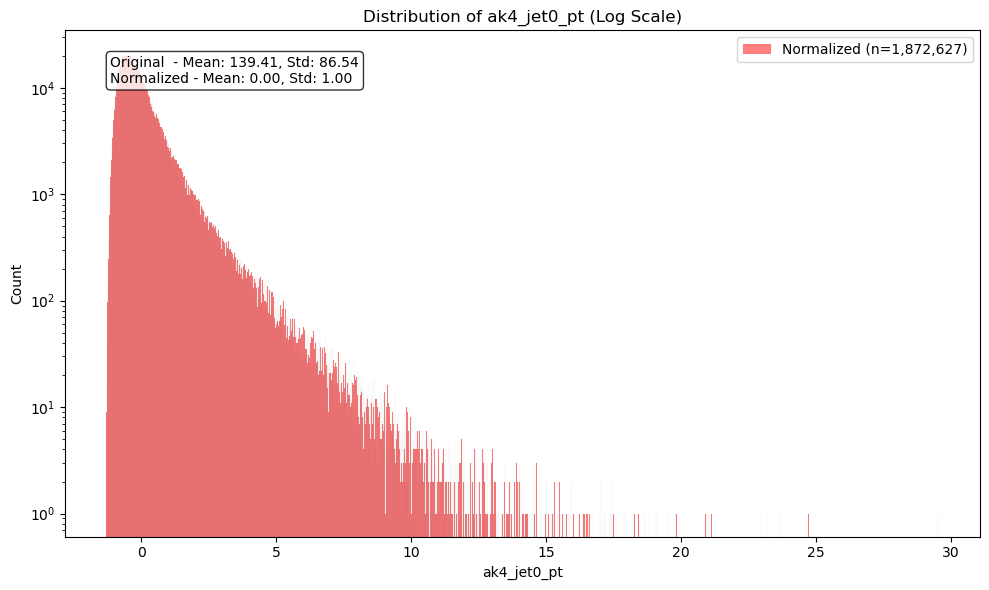

In [11]:
def plot_feature_comparison(X_train, X_normalized, feature_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # sns.histplot(data=X_train, x=feature_name, label=f'Original (n={len(X_train):,})', alpha=0.5, color='blue')
    sns.histplot(data=X_normalized, x=feature_name, label=f'Normalized (n={len(X_normalized):,})', alpha=0.5, color='red')
    
    plt.title(f'Distribution of {feature_name} (Log Scale)')
    plt.xlabel(f'{feature_name}')
    plt.ylabel('Count')
    plt.yscale('log')  # Set y-axis to log scale
    plt.legend()
    
    # Add statistics text
    stats_text = (
        f'Original  - Mean: {X_train[feature_name].mean():.2f}, Std: {X_train[feature_name].std():.2f}\n'
        f'Normalized - Mean: {X_normalized[feature_name].mean():.2f}, Std: {X_normalized[feature_name].std():.2f}'
    )
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_feature_comparison(X_train, X_normalized1, 'ak4_jet0_pt')

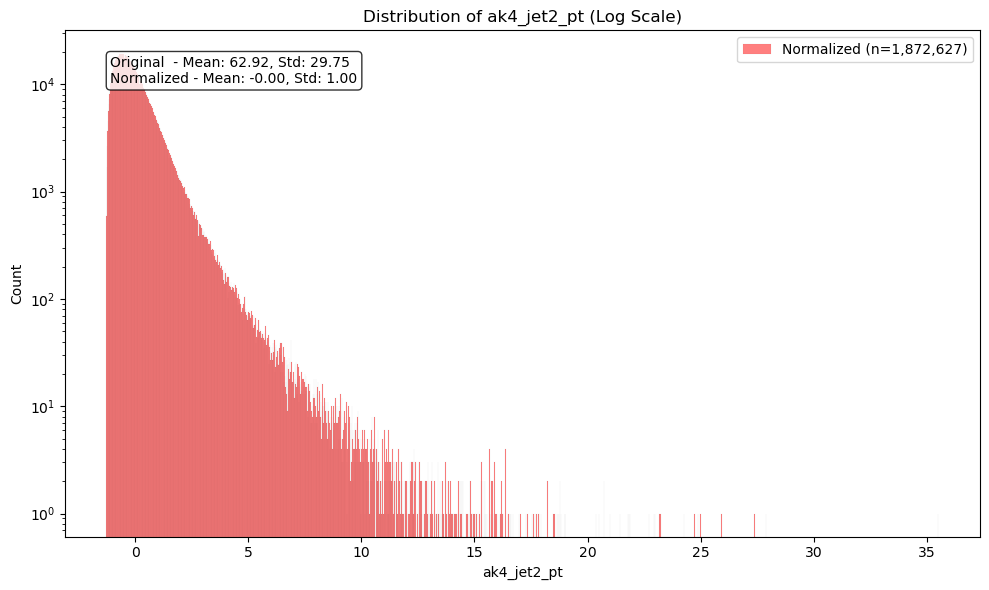

In [12]:
plot_feature_comparison(X_train, X_normalized, 'ak4_jet2_pt')

In [33]:
min_of_all_features = X_normalized.describe().round(2).loc[['min']]
min_of_all_features

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
min,-0.75,-0.26,-1.16,-2.32,-1.73,-1.3,-2.12,-1.73,-1.34,-2.1,-1.73,-1.27,-2.04,-1.73,-1.3,-2.23,-1.73,-1.06,-2.13,-1.73,-1.42,-1.73,-1.39,-1.5,-3.46,-2.4,-1.49,-1.33,-1.73,-3.66,-1.94,-1.69,-1.16,-4.24,-2.25,-2.03,-1.11,-1.57,-1.44,-0.98


In [31]:
min(min(min_of_all_features.values.tolist()))

-4.24

In [16]:
(X_normalized + 3).describe().round(2)


,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00
mean,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,2.25,2.74,1.84,0.68,1.27,1.70,0.88,1.27,1.66,0.90,1.27,1.73,0.96,1.27,1.70,0.77,1.27,1.94,0.87,1.27,1.58,1.27,1.61,1.50,-0.46,0.60,1.51,1.67,1.27,-0.66,1.06,1.31,1.84,-1.24,0.75,0.97,1.89,1.43,1.56,2.02
25%,2.25,2.74,2.34,2.27,2.13,2.40,2.25,2.14,2.38,2.25,2.13,2.34,2.24,2.13,2.38,2.26,2.14,2.30,2.25,2.13,2.33,2.13,2.35,2.02,2.30,2.29,2.36,2.39,2.36,2.30,2.35,2.35,2.33,2.53,2.26,2.16,2.39,2.34,2.36,2.46
50%,2.25,2.74,2.73,3.00,3.00,2.74,3.00,3.00,2.77,3.00,3.00,2.77,3.00,3.00,2.78,3.00,3.00,2.74,3.00,3.00,2.79,3.00,2.77,3.00,3.00,3.11,2.84,2.68,2.79,3.10,2.79,2.80,2.69,3.00,2.91,3.00,2.74,2.74,2.76,2.65
75%,3.36,2.74,3.35,3.73,3.87,3.26,3.75,3.87,3.33,3.75,3.87,3.37,3.76,3.87,3.34,3.74,3.87,3.40,3.75,3.87,3.41,3.87,3.37,3.98,3.70,3.74,3.40,3.29,3.37,3.82,3.39,3.42,3.32,3.47,3.65,3.84,3.27,3.35,3.34,3.19
max,12.19,17.54,34.44,5.32,4.73,32.54,5.12,4.73,40.84,5.10,4.73,38.50,5.04,4.73,42.85,5.23,4.73,40.87,5.13,4.73,70.09,4.73,36.74,4.51,6.47,7.03,29.71,30.68,29.92,4.63,36.13,43.34,14.58,7.23,12.22,5.03,102.60,23.26,30.10,36.27


In [38]:
from tensorflow.keras import losses as tf_losses

In [42]:
tf_losses.get('categorical_crossentropy')

<function keras.src.losses.losses.categorical_crossentropy(y_true, y_pred, from_logits=False, label_smoothing=0.0, axis=-1)>